# 01 - Exploratory Data Analysis (EDA)

**StormVision**: Small-object detection in maritime drone imagery.

This notebook performs comprehensive EDA on the dataset:
1. Load and parse COCO annotations into DataFrame
2. Class frequency analysis
3. Bounding box size analysis (focus on small objects)
4. Image visualizations
5. Data quality conclusions

## Configuration

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')


SEED = 42

from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

# Project root - hardcoded for Colab with Drive
PROJECT_ROOT = Path('/content/drive/MyDrive/StormVision')

# Visualization settings
N_RANDOM_SAMPLES = 20
N_MOST_OBJECTS = 10
N_SMALLEST_OBJECTS = 10

# Small object threshold (area in pixels^2)
SMALL_OBJECT_THRESHOLD = 1024  # 32x32 pixels

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:


# Set seeds
random.seed(SEED)
np.random.seed(SEED)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths
PROJECT_ROOT = Path(PROJECT_ROOT).resolve()
DATA_PATH = PROJECT_ROOT / 'data'
TRAIN_IMAGES = DATA_PATH / 'train'
VAL_IMAGES = DATA_PATH / 'val'
ANNOTATIONS = DATA_PATH / 'annotations'
FIGURES_PATH = PROJECT_ROOT / 'results' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f'[DIR] Project Root: {PROJECT_ROOT}')
print(f' Figures will be saved to: {FIGURES_PATH}')

[DIR] Project Root: /content/drive/MyDrive/StormVision
 Figures will be saved to: /content/drive/MyDrive/StormVision/results/figures


## 1. Load COCO Annotations

In [5]:
def load_coco_annotations(ann_path):
    """Load COCO JSON annotations."""
    with open(ann_path) as f:
        return json.load(f)

# Load train and val annotations
train_ann = load_coco_annotations(ANNOTATIONS / 'instances_train.json')
val_ann = load_coco_annotations(ANNOTATIONS / 'instances_val.json')

# Extract categories
CATEGORIES = {cat['id']: cat['name'] for cat in train_ann['categories']}
print(' Categories:')
for cat_id, cat_name in CATEGORIES.items():
    print(f'   {cat_id}: {cat_name}')

print(f'\n Dataset Summary:')
print(f'   Train: {len(train_ann["images"]):,} images, {len(train_ann["annotations"]):,} annotations')
print(f'   Val:   {len(val_ann["images"]):,} images, {len(val_ann["annotations"]):,} annotations')

 Categories:
   0: ignored
   1: swimmer
   2: boat
   3: jetski
   4: life_saving_appliances
   5: buoy

 Dataset Summary:
   Train: 8,930 images, 57,760 annotations
   Val:   1,547 images, 9,630 annotations


## 2. Build Analysis DataFrame

In [6]:
def build_analysis_dataframe(coco_data, split_name, images_dir):
    """
    Build a comprehensive DataFrame for analysis.

    Columns:
    - image_id, file_name, image_path, split
    - width, height, n_objects
    - class_counts (dict), bbox stats
    """
    # Build image info dict
    img_info = {img['id']: img for img in coco_data['images']}

    # Group annotations by image
    img_to_anns = defaultdict(list)
    for ann in coco_data['annotations']:
        img_to_anns[ann['image_id']].append(ann)

    rows = []
    for img_id, img in img_info.items():
        anns = img_to_anns.get(img_id, [])

        # Class counts
        class_counts = Counter(CATEGORIES.get(ann['category_id'], 'unknown') for ann in anns)

        # Bbox stats
        bbox_areas = [ann['bbox'][2] * ann['bbox'][3] for ann in anns]
        bbox_widths = [ann['bbox'][2] for ann in anns]
        bbox_heights = [ann['bbox'][3] for ann in anns]

        row = {
            'image_id': img_id,
            'file_name': img['file_name'],
            'image_path': str(images_dir / img['file_name']),
            'split': split_name,
            'width': img['width'],
            'height': img['height'],
            'n_objects': len(anns),
            'class_counts': dict(class_counts),
            'min_bbox_area': min(bbox_areas) if bbox_areas else 0,
            'max_bbox_area': max(bbox_areas) if bbox_areas else 0,
            'mean_bbox_area': np.mean(bbox_areas) if bbox_areas else 0,
            'min_bbox_width': min(bbox_widths) if bbox_widths else 0,
            'max_bbox_width': max(bbox_widths) if bbox_widths else 0,
            'min_bbox_height': min(bbox_heights) if bbox_heights else 0,
            'max_bbox_height': max(bbox_heights) if bbox_heights else 0,
            'has_small_object': any(a < SMALL_OBJECT_THRESHOLD for a in bbox_areas),
        }
        rows.append(row)

    return pd.DataFrame(rows)

# Build DataFrames
df_train = build_analysis_dataframe(train_ann, 'train', TRAIN_IMAGES)
df_val = build_analysis_dataframe(val_ann, 'val', VAL_IMAGES)

# Combine
df = pd.concat([df_train, df_val], ignore_index=True)

print(f' Analysis DataFrame: {len(df)} images')
print(f'\n{df.head()}')

 Analysis DataFrame: 10477 images

   image_id file_name                                         image_path  \
0      3388  3388.jpg  /content/drive/MyDrive/StormVision/data/train/...   
1      3389  3389.jpg  /content/drive/MyDrive/StormVision/data/train/...   
2      3390  3390.jpg  /content/drive/MyDrive/StormVision/data/train/...   
3      3391  3391.jpg  /content/drive/MyDrive/StormVision/data/train/...   
4      3392  3392.jpg  /content/drive/MyDrive/StormVision/data/train/...   

   split  width  height  n_objects class_counts  min_bbox_area  max_bbox_area  \
0  train   3840    2160          1  {'boat': 1}           2850           2850   
1  train   3840    2160          1  {'boat': 1}           2701           2701   
2  train   3840    2160          1  {'boat': 1}           2556           2556   
3  train   3840    2160          1  {'boat': 1}           2450           2450   
4  train   3840    2160          1  {'boat': 1}           2145           2145   

   mean_bbox_area  mi

In [7]:
# Build annotations DataFrame for detailed analysis
def build_annotations_dataframe(coco_data, split_name):
    """Build DataFrame of individual annotations."""
    img_info = {img['id']: img for img in coco_data['images']}

    rows = []
    for ann in coco_data['annotations']:
        img = img_info.get(ann['image_id'], {})
        bbox = ann['bbox']  # [x, y, w, h]

        row = {
            'ann_id': ann['id'],
            'image_id': ann['image_id'],
            'file_name': img.get('file_name', ''),
            'split': split_name,
            'category_id': ann['category_id'],
            'category_name': CATEGORIES.get(ann['category_id'], 'unknown'),
            'bbox_x': bbox[0],
            'bbox_y': bbox[1],
            'bbox_w': bbox[2],
            'bbox_h': bbox[3],
            'bbox_area': bbox[2] * bbox[3],
            'aspect_ratio': bbox[2] / bbox[3] if bbox[3] > 0 else 0,
            'img_width': img.get('width', 0),
            'img_height': img.get('height', 0),
            'relative_area': (bbox[2] * bbox[3]) / (img.get('width', 1) * img.get('height', 1)),
        }
        rows.append(row)

    return pd.DataFrame(rows)

df_ann_train = build_annotations_dataframe(train_ann, 'train')
df_ann_val = build_annotations_dataframe(val_ann, 'val')
df_ann = pd.concat([df_ann_train, df_ann_val], ignore_index=True)

print(f' Annotations DataFrame: {len(df_ann)} annotations')
print(f'\n{df_ann.head()}')

 Annotations DataFrame: 67390 annotations

   ann_id  image_id file_name  split  category_id category_name  bbox_x  \
0   14579      3388  3388.jpg  train            2          boat    3619   
1   14581      3389  3389.jpg  train            2          boat    3524   
2   14583      3390  3390.jpg  train            2          boat    3399   
3   14585      3391  3391.jpg  train            2          boat    3267   
4   14587      3392  3392.jpg  train            2          boat    3053   

   bbox_y  bbox_w  bbox_h  bbox_area  aspect_ratio  img_width  img_height  \
0    1409      75      38       2850      1.973684       3840        2160   
1    1408      73      37       2701      1.972973       3840        2160   
2    1406      71      36       2556      1.972222       3840        2160   
3    1152      70      35       2450      2.000000       3840        2160   
4     784      65      33       2145      1.969697       3840        2160   

   relative_area  
0       0.000344  
1    

## 3. Class Frequency Analysis

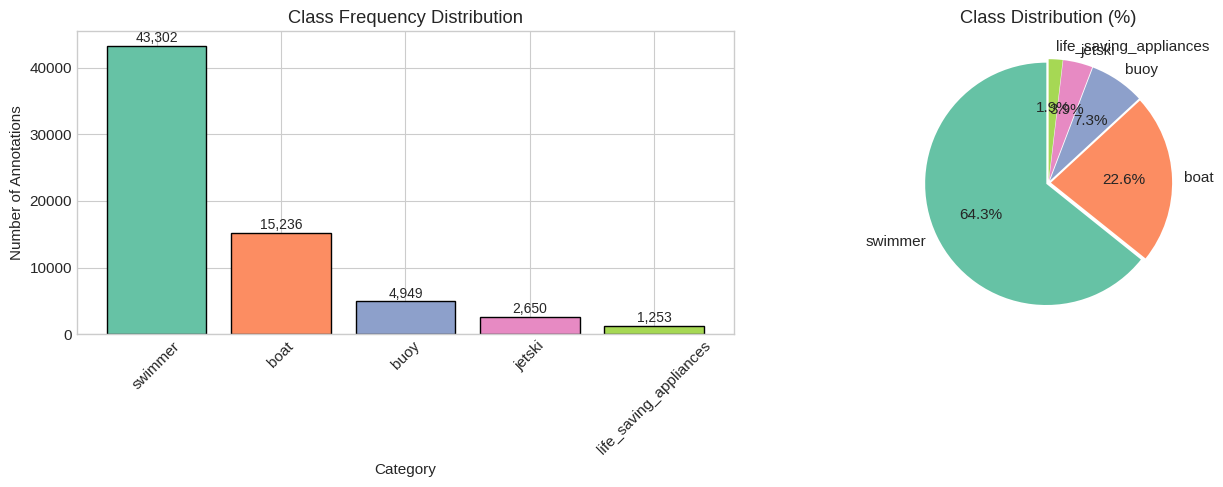


 Class Distribution Summary:
                        Count  Percentage
category_name                            
swimmer                 43302       64.26
boat                    15236       22.61
buoy                     4949        7.34
jetski                   2650        3.93
life_saving_appliances   1253        1.86


In [8]:
# Class distribution
class_counts = df_ann['category_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = plt.cm.Set2(range(len(class_counts)))
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Annotations')
axes[0].set_title('Class Frequency Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Add count labels
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, explode=[0.02]*len(class_counts), startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print('\n Class Distribution Summary:')
summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage': (class_counts / class_counts.sum() * 100).round(2)
})
print(summary.to_string())

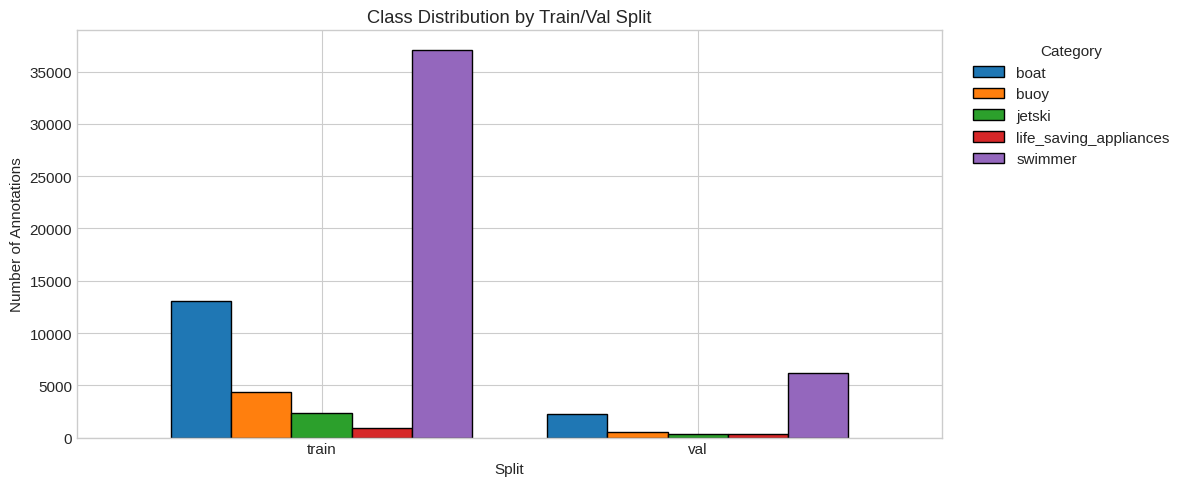


 Class Distribution by Split:
category_name   boat  buoy  jetski  life_saving_appliances  swimmer
split                                                              
train          13022  4389    2330                     923    37096
val             2214   560     320                     330     6206


In [9]:
# Class distribution by split
split_class_counts = df_ann.groupby(['split', 'category_name']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
split_class_counts.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_xlabel('Split')
ax.set_ylabel('Number of Annotations')
ax.set_title('Class Distribution by Train/Val Split')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'class_distribution_by_split.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Class Distribution by Split:')
print(split_class_counts.to_string())

## 4. Bounding Box Size Analysis

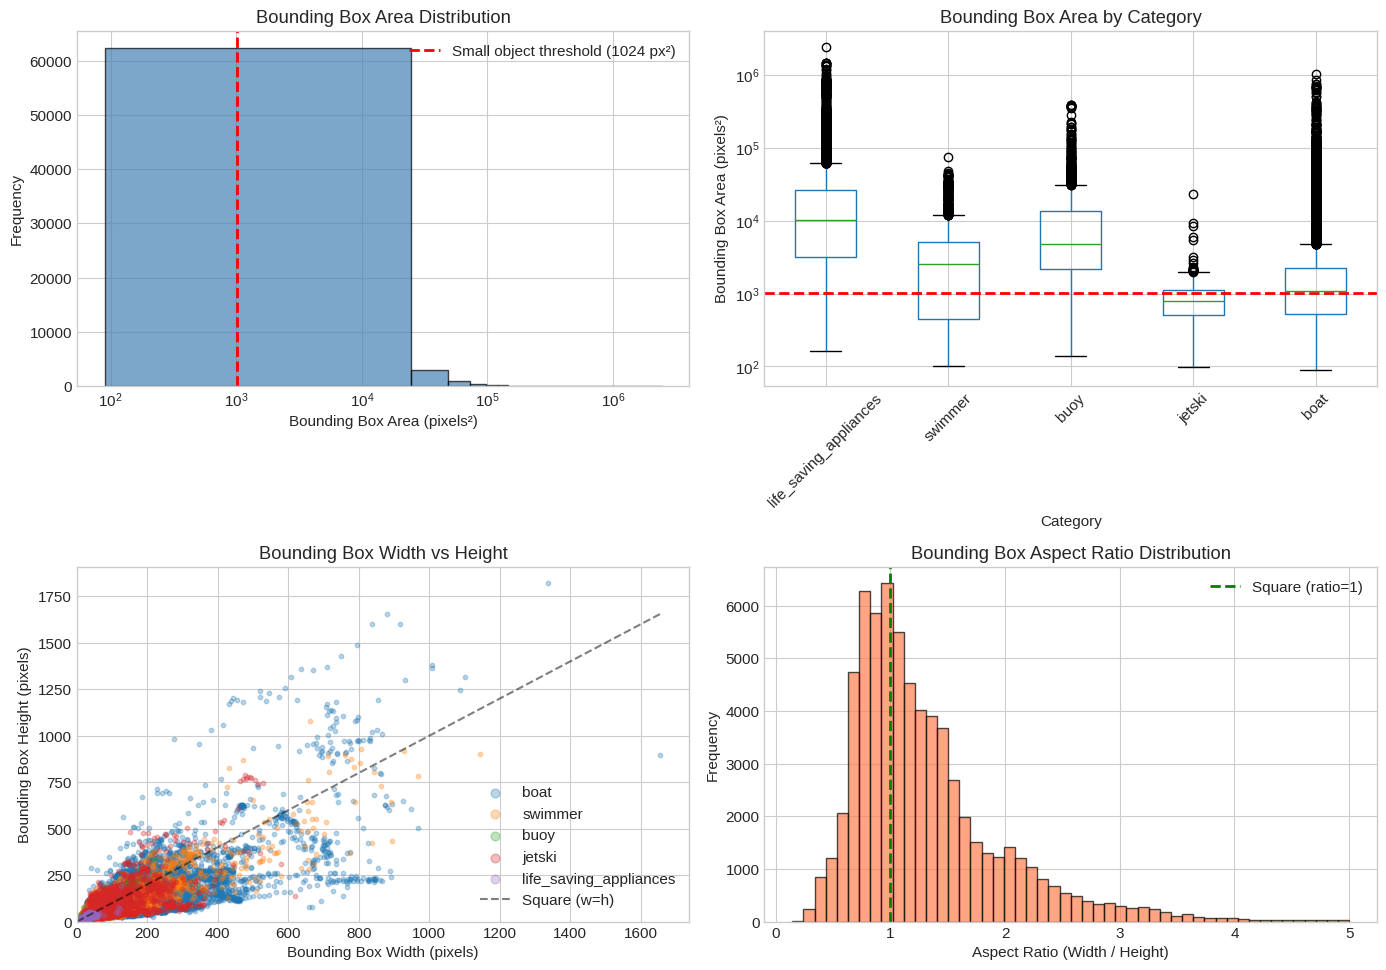

In [10]:
# Remove 'ignored' category for bbox analysis
df_ann_valid = df_ann[df_ann['category_name'] != 'ignored'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bbox area distribution (log scale)
ax = axes[0, 0]
ax.hist(df_ann_valid['bbox_area'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(SMALL_OBJECT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Small object threshold ({SMALL_OBJECT_THRESHOLD} px²)')
ax.set_xlabel('Bounding Box Area (pixels²)')
ax.set_ylabel('Frequency')
ax.set_title('Bounding Box Area Distribution')
ax.set_xscale('log')
ax.legend()

# 2. Bbox area by category
ax = axes[0, 1]
categories_ordered = df_ann_valid.groupby('category_name')['bbox_area'].median().sort_values().index
df_ann_valid.boxplot(column='bbox_area', by='category_name', ax=ax,
                      positions=range(len(categories_ordered)))
ax.set_xticklabels(categories_ordered, rotation=45)
ax.axhline(SMALL_OBJECT_THRESHOLD, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Category')
ax.set_ylabel('Bounding Box Area (pixels²)')
ax.set_title('Bounding Box Area by Category')
ax.set_yscale('log')
plt.suptitle('')  # Remove automatic title

# 3. Width vs Height distribution
ax = axes[1, 0]
for cat in df_ann_valid['category_name'].unique():
    cat_data = df_ann_valid[df_ann_valid['category_name'] == cat]
    ax.scatter(cat_data['bbox_w'], cat_data['bbox_h'], alpha=0.3, label=cat, s=10)
ax.plot([0, df_ann_valid['bbox_w'].max()], [0, df_ann_valid['bbox_w'].max()],
        'k--', alpha=0.5, label='Square (w=h)')
ax.set_xlabel('Bounding Box Width (pixels)')
ax.set_ylabel('Bounding Box Height (pixels)')
ax.set_title('Bounding Box Width vs Height')
ax.legend(markerscale=2)
ax.set_xlim(0, None)
ax.set_ylim(0, None)

# 4. Aspect ratio distribution
ax = axes[1, 1]
df_ann_valid['aspect_ratio'].clip(0, 5).hist(bins=50, ax=ax, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(1, color='green', linestyle='--', linewidth=2, label='Square (ratio=1)')
ax.set_xlabel('Aspect Ratio (Width / Height)')
ax.set_ylabel('Frequency')
ax.set_title('Bounding Box Aspect Ratio Distribution')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'bbox_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Small object analysis
df_ann_valid['is_small'] = df_ann_valid['bbox_area'] < SMALL_OBJECT_THRESHOLD

small_stats = df_ann_valid.groupby('category_name').agg({
    'ann_id': 'count',
    'is_small': 'sum',
    'bbox_area': ['min', 'median', 'max']
}).round(1)

small_stats.columns = ['Total', 'Small Objects', 'Min Area', 'Median Area', 'Max Area']
small_stats['% Small'] = (small_stats['Small Objects'] / small_stats['Total'] * 100).round(1)

print('=' * 70)
print('SMALL OBJECT ANALYSIS (Area < {:,} px²)'.format(SMALL_OBJECT_THRESHOLD))
print('=' * 70)
print(small_stats.to_string())

total_small = df_ann_valid['is_small'].sum()
total_all = len(df_ann_valid)
print(f'\n Overall: {total_small:,} / {total_all:,} ({total_small/total_all*100:.1f}%) objects are small')

SMALL OBJECT ANALYSIS (Area < 1,024 px²)
                        Total  Small Objects  Min Area  Median Area  Max Area  % Small
category_name                                                                         
boat                    15236           1506       165      10318.5   2433340      9.9
buoy                     4949           1555       100       2520.0     74140     31.4
jetski                   2650            289       140       4788.0    393669     10.9
life_saving_appliances   1253            863        99        780.0     23436     68.9
swimmer                 43302          20524        90       1092.0   1034176     47.4

 Overall: 24,737 / 67,390 (36.7%) objects are small


## 5. Image Visualizations

In [12]:
def get_category_colors():
    """Get distinct colors for categories."""
    cmap = plt.cm.get_cmap('tab10')
    return {cat_id: cmap(i % 10) for i, cat_id in enumerate(CATEGORIES.keys())}

CAT_COLORS = get_category_colors()

def visualize_image_with_boxes(img_path, annotations, ax, title=''):
    """Draw image with bounding boxes."""
    if Path(img_path).exists():
        img = Image.open(img_path)
        ax.imshow(img)

        for ann in annotations:
            bbox = [ann['bbox_x'], ann['bbox_y'], ann['bbox_w'], ann['bbox_h']]
            cat_id = ann['category_id']
            cat_name = ann['category_name']
            color = CAT_COLORS.get(cat_id, 'red')

            rect = patches.Rectangle(
                (bbox[0], bbox[1]), bbox[2], bbox[3],
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(bbox[0], bbox[1] - 3, cat_name, fontsize=7, color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(title, fontsize=9)
    ax.axis('off')

def visualize_grid(image_ids, df_annotations, images_base, title, n_cols=5, figsize=(20, 12)):
    """Visualize a grid of images."""
    n_images = len(image_ids)
    n_rows = (n_images + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_images > 1 else [axes]

    for idx, img_id in enumerate(image_ids):
        img_anns = df_annotations[df_annotations['image_id'] == img_id]
        if len(img_anns) > 0:
            file_name = img_anns.iloc[0]['file_name']
            split = img_anns.iloc[0]['split']
            img_path = images_base.parent / split / file_name

            visualize_image_with_boxes(
                img_path,
                img_anns.to_dict('records'),
                axes[idx],
                f'{file_name} ({len(img_anns)} obj)'
            )

    # Hide empty axes
    for idx in range(n_images, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(title, fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()
    return fig

In [13]:
# 5.1 Random samples
print('=' * 60)
print(f'5.1 RANDOM SAMPLES ({N_RANDOM_SAMPLES} images)')
print('=' * 60)

random_ids = df_ann['image_id'].drop_duplicates().sample(n=min(N_RANDOM_SAMPLES, len(df)), random_state=SEED).tolist()
fig = visualize_grid(random_ids, df_ann, TRAIN_IMAGES, f'{N_RANDOM_SAMPLES} Random Images with Ground Truth', n_cols=5)
plt.savefig(FIGURES_PATH / 'random_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

5.2 IMAGES WITH MOST OBJECTS (10 images)


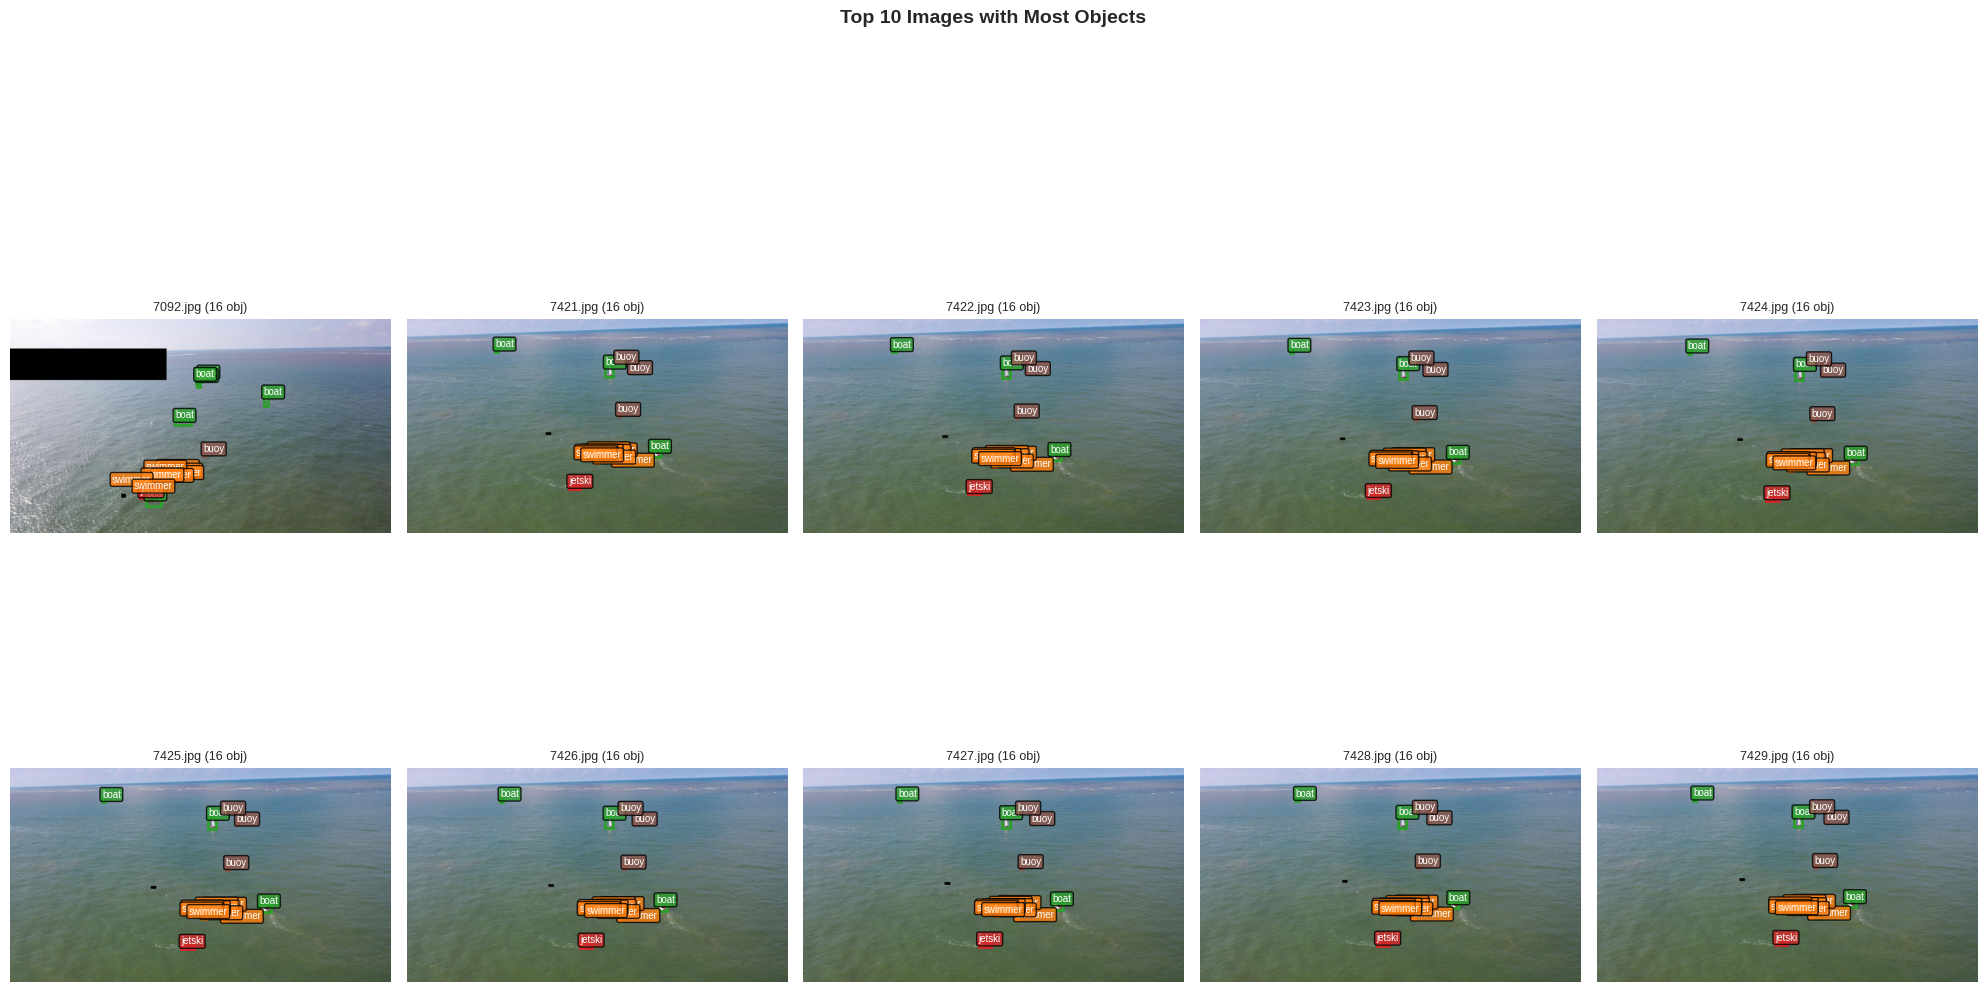


Top images by object count:
     file_name  n_objects  split
2346  7092.jpg         16  train
2461  7421.jpg         16  train
2462  7422.jpg         16  train
2463  7423.jpg         16  train
2464  7424.jpg         16  train
2465  7425.jpg         16  train
2466  7426.jpg         16  train
2467  7427.jpg         16  train
2468  7428.jpg         16  train
2469  7429.jpg         16  train


In [14]:
# 5.2 Images with most objects
print('=' * 60)
print(f'5.2 IMAGES WITH MOST OBJECTS ({N_MOST_OBJECTS} images)')
print('=' * 60)

most_obj_ids = df.nlargest(N_MOST_OBJECTS, 'n_objects')['image_id'].tolist()
fig = visualize_grid(most_obj_ids, df_ann, TRAIN_IMAGES, f'Top {N_MOST_OBJECTS} Images with Most Objects', n_cols=5)
plt.savefig(FIGURES_PATH / 'most_objects.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop images by object count:')
print(df.nlargest(N_MOST_OBJECTS, 'n_objects')[['file_name', 'n_objects', 'split']].to_string())

5.3 IMAGES WITH SMALLEST OBJECTS (10 images)


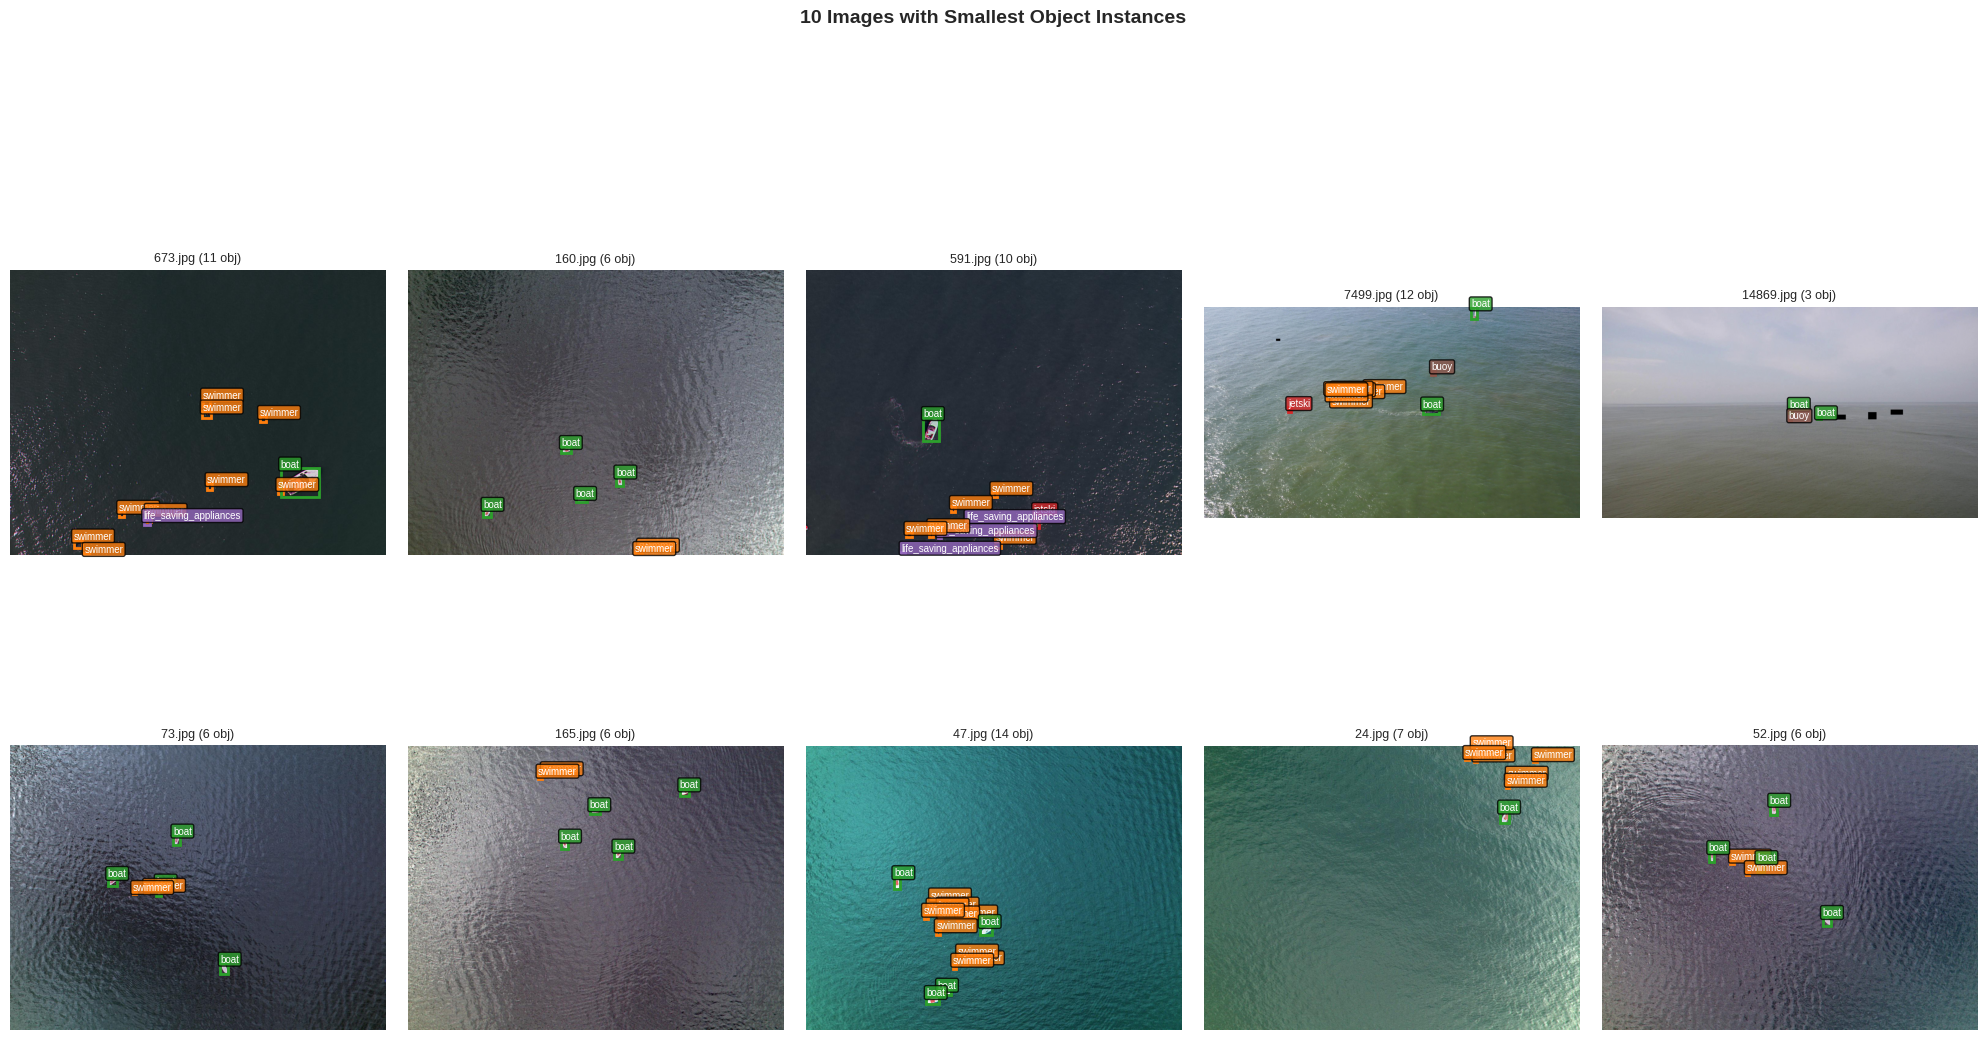


Images with smallest objects:
      file_name  min_bbox_area  n_objects  split
8430    673.jpg             90         11  train
8924    160.jpg             96          6  train
8794    591.jpg             99         10  train
2539   7499.jpg            100         12  train
6229  14869.jpg            100          3  train
7479     73.jpg            100          6  train
7789    165.jpg            100          6  train
7863     47.jpg            100         14  train
7901     24.jpg            100          7  train
7965     52.jpg            100          6  train


In [15]:
# 5.3 Images with smallest objects
print('=' * 60)
print(f'5.3 IMAGES WITH SMALLEST OBJECTS ({N_SMALLEST_OBJECTS} images)')
print('=' * 60)

# Get images that have small objects, sorted by minimum bbox area
small_obj_df = df[df['min_bbox_area'] > 0].nsmallest(N_SMALLEST_OBJECTS, 'min_bbox_area')
smallest_ids = small_obj_df['image_id'].tolist()

fig = visualize_grid(smallest_ids, df_ann, TRAIN_IMAGES, f'{N_SMALLEST_OBJECTS} Images with Smallest Object Instances', n_cols=5)
plt.savefig(FIGURES_PATH / 'smallest_objects.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nImages with smallest objects:')
print(small_obj_df[['file_name', 'min_bbox_area', 'n_objects', 'split']].to_string())

## 6. Image Size Analysis

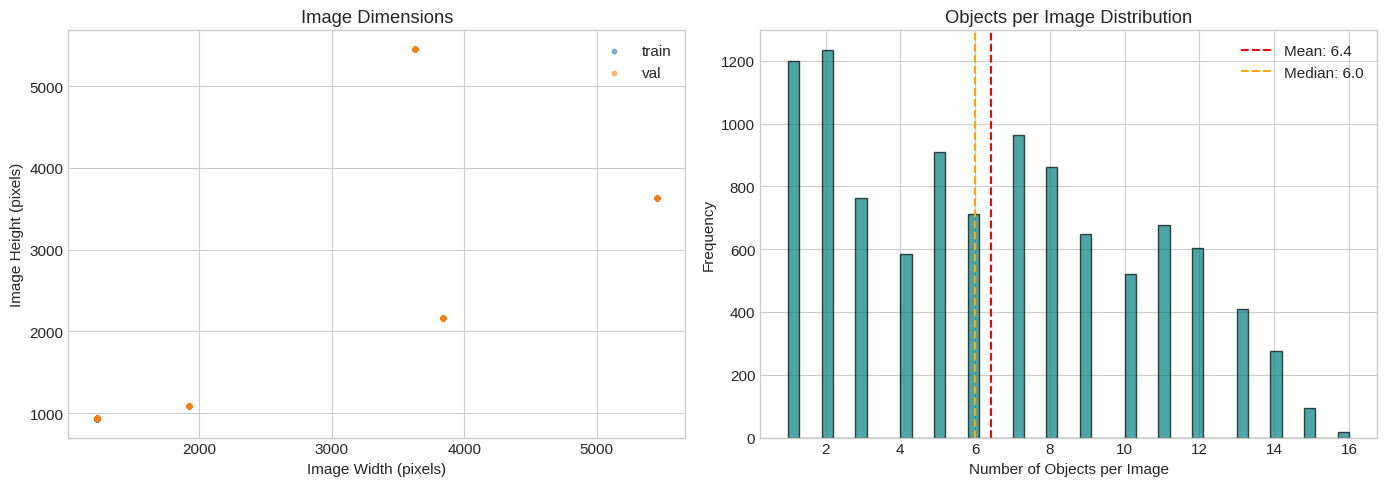


 Image Size Statistics:
   Unique sizes: 24
    width  height  count
22   3840    2160   6830
20   1920    1080   1834
23   5456    3632   1009
21   3632    5456    329
9    1230     933    139


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Image sizes scatter
ax = axes[0]
for split in ['train', 'val']:
    split_df = df[df['split'] == split]
    ax.scatter(split_df['width'], split_df['height'], alpha=0.5, label=split, s=10)
ax.set_xlabel('Image Width (pixels)')
ax.set_ylabel('Image Height (pixels)')
ax.set_title('Image Dimensions')
ax.legend()

# Objects per image distribution
ax = axes[1]
df['n_objects'].hist(bins=50, ax=ax, color='teal', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Objects per Image')
ax.set_ylabel('Frequency')
ax.set_title('Objects per Image Distribution')
ax.axvline(df['n_objects'].mean(), color='red', linestyle='--', label=f'Mean: {df["n_objects"].mean():.1f}')
ax.axvline(df['n_objects'].median(), color='orange', linestyle='--', label=f'Median: {df["n_objects"].median():.1f}')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'image_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Image Size Statistics:')
print(f'   Unique sizes: {df.groupby(["width", "height"]).size().reset_index(name="count").shape[0]}')
print(df.groupby(['width', 'height']).size().reset_index(name='count').nlargest(5, 'count').to_string())

## 7. Data Quality Summary & Conclusions

In [17]:
print('=' * 70)
print('EDA SUMMARY & CONCLUSIONS')
print('=' * 70)

# Calculate key statistics
total_images = len(df)
total_annotations = len(df_ann)
avg_objects = df['n_objects'].mean()
pct_small = (df_ann_valid['is_small'].sum() / len(df_ann_valid) * 100)

# Primary classes (swimmer, boat)
primary_classes = ['swimmer', 'boat']
primary_count = df_ann[df_ann['category_name'].isin(primary_classes)].shape[0]
primary_pct = primary_count / total_annotations * 100

conclusions = f"""
 DATASET OVERVIEW:
   • Total images: {total_images:,} (Train: {len(df_train):,}, Val: {len(df_val):,})
   • Total annotations: {total_annotations:,}
   • Average objects per image: {avg_objects:.1f}
   • Number of classes: {len(CATEGORIES)} ({', '.join(CATEGORIES.values())})

 KEY FINDINGS:

   1. CLASS IMBALANCE:
      • Primary target classes (swimmer, boat) represent {primary_pct:.1f}% of annotations
      • Most common: {class_counts.index[0]} ({class_counts.values[0]:,} annotations)
      • Least common: {class_counts.index[-1]} ({class_counts.values[-1]:,} annotations)

   2. SMALL OBJECT CHALLENGE:
      • {pct_small:.1f}% of objects are "small" (area < {SMALL_OBJECT_THRESHOLD} px²)
      • Swimmers and people tend to be the smallest objects
      • This justifies focus on small-object detection techniques

   3. IMAGE CHARACTERISTICS:
      • Maritime drone footage with varying altitudes
      • Mix of sea surface textures (calm to moderately rough)
      • Objects often appear against water background

   4. DATA QUALITY:
      • Images with no annotations: {(df['n_objects'] == 0).sum()}
      • Annotation format: COCO JSON (well-structured)
      • Bounding boxes appear correctly aligned

 RECOMMENDATIONS FOR SYNTHETIC GENERATION:
   • Focus storm augmentation on sea/sky background only
   • Preserve object regions carefully (especially small swimmers)
   • Maintain realistic lighting and water texture consistency
   • Consider class-balanced sampling for training
"""

print(conclusions)

# Save conclusions
with open(FIGURES_PATH / 'eda_conclusions.txt', 'w') as f:
    f.write(conclusions)

print(f'\n All figures saved to: {FIGURES_PATH}')
print(f'   • class_distribution.png')
print(f'   • class_distribution_by_split.png')
print(f'   • bbox_analysis.png')
print(f'   • random_samples.png')
print(f'   • most_objects.png')
print(f'   • smallest_objects.png')
print(f'   • image_analysis.png')
print(f'   • eda_conclusions.txt')

EDA SUMMARY & CONCLUSIONS

 DATASET OVERVIEW:
   • Total images: 10,477 (Train: 8,930, Val: 1,547)
   • Total annotations: 67,390
   • Average objects per image: 6.4
   • Number of classes: 6 (ignored, swimmer, boat, jetski, life_saving_appliances, buoy)

 KEY FINDINGS:

   1. CLASS IMBALANCE:
      • Primary target classes (swimmer, boat) represent 86.9% of annotations
      • Most common: swimmer (43,302 annotations)
      • Least common: life_saving_appliances (1,253 annotations)

   2. SMALL OBJECT CHALLENGE:
      • 36.7% of objects are "small" (area < 1024 px²)
      • Swimmers and people tend to be the smallest objects
      • This justifies focus on small-object detection techniques

   3. IMAGE CHARACTERISTICS:
      • Maritime drone footage with varying altitudes
      • Mix of sea surface textures (calm to moderately rough)
      • Objects often appear against water background

   4. DATA QUALITY:
      • Images with no annotations: 0
      • Annotation format: COCO JSON (we